In [167]:
#import pulearn
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score
from pulearn import ElkanotoPuClassifier
import matplotlib.pyplot as plt
from collections import Counter
from copy import deepcopy

In [9]:
seed = 42

In [51]:
def prepreprocess(df):
    drop_cols = [col for col in df.columns if col in ["ID", "newID", "pyrkey"] or col.startswith("sample")]
    df = df.drop(columns=drop_cols)
    df = pd.get_dummies(df,drop_first=False)
    return df

def preprocess_pu_data(df):
    """Remove ID/sample columns and extract features and labels."""
    # Drop ID and sample columns

    X = df.drop(columns=["germ"])
    y = df["germ"].values.astype(int)
    return X.values, y

In [70]:
def balance_pu_dataset(df, pos_col="germ", ratio=1.0, random_state=42):
    """Downsample positives to match a given ratio of positives to unlabeled examples."""
    pos = df[df[pos_col] == 1]
    unlabeled = df[df[pos_col] == 0]

    n_unlabeled = len(unlabeled)
    n_pos_sample = int(n_unlabeled * ratio)

    pos_sample = pos.sample(n=n_pos_sample, random_state=random_state)

    balanced_df = pd.concat([pos_sample, unlabeled]).sample(frac=1, random_state=random_state).reset_index(drop=True)
    return balanced_df

In [119]:
def train_pu_classifier(train_df, random_state=42, n_jobs=-1):
    """Train a PU learning classifier using pulearn."""
    X_train, y_train = preprocess_pu_data(train_df)

    base_estimator = RandomForestClassifier(
        n_estimators=100,
        random_state=random_state,
        n_jobs=n_jobs,
    )
    pu_clf = ElkanotoPuClassifier(estimator=base_estimator)
    pu_clf.fit(X_train, y_train)

    return pu_clf

In [120]:
def apply_pu_classifier(pu_clf, test_df):
    """Apply trained classifier to new dataset."""
    X_test, _ = preprocess_pu_data(test_df)  # you can ignore y here
    preds = pu_clf.predict(X_test)
    probs = pu_clf.predict_proba(X_test)[:, 1]  # probability of being positive
    return preds, probs

In [89]:
def ensemble_predict(models, test_df, threshold=0.5):
    X_test, _ = preprocess_pu_data(test_df)
    all_probs = []

    for model in models:
        probs = model.predict_proba(X_test)[:, 1]  # P(y=1|x)
        all_probs.append(probs)

    # Average predicted probabilities
    avg_probs = np.mean(all_probs, axis=0)
    # Majority vote at threshold 0.5
    votes = (avg_probs >= threshold).astype(int)

    return votes, avg_probs

In [163]:
def find_best_threshold(y_true, y_probs, metric='f1', step=0.01, verbose=True, macro=True):
    """
    Search for the best threshold that maximizes a given metric.

    Parameters:
    - y_true: True binary labels
    - y_probs: Predicted probabilities (P(y=1|x))
    - metric: 'f1', 'precision', or 'recall'
    - step: Granularity of threshold search
    - verbose: Whether to print progress

    Returns:
    - best_thresh: Threshold with best score
    - best_score: Best score achieved
    """
    best_thresh = 0.5
    best_score = -1
    thresholds = np.arange(0.01, 0.99, step)

    for thresh in thresholds:
        y_pred = (y_probs >= thresh).astype(int)
        if metric == 'f1':
            if macro==True:
                score = f1_score(y_true, y_pred, average='macro')
            else:
                score = f1_score(y_true, y_pred)
        elif metric == 'precision':
            score = precision_score(y_true, y_pred)
        elif metric == 'recall':
            score = recall_score(y_true, y_pred)
        else:
            raise ValueError("Unsupported metric: choose from 'f1', 'precision', 'recall'")
        
        if score > best_score:
            best_score = score
            best_thresh = thresh
    
    if verbose:
        print(f"Best {metric} score: {best_score:.3f} at threshold {best_thresh:.2f}")
    
    return best_thresh, best_score

In [52]:
# import tables
somvar_all = pd.read_csv('../data/somatic_muts_with_germ_and_double.csv', index_col=0)
somvar_al_dummies = prepreprocess(somvar_all)

In [54]:
# SHUFFLE AND PARTITION
shuffled_df = somvar_al_dummies.sample(frac=1, random_state=42).reset_index(drop=True)
train = shuffled_df.iloc[0:650,]
test =  shuffled_df.iloc[651:1301,]
bench = shuffled_df.iloc[1302:,]

In [118]:
# DOWNSAMPLE AND BOOTSTRAP BALANCED SUBSETS
N_bootstraps = 30
downsampled_balanced = []
for i in range(N_bootstraps):
    downsampled_balanced.append(balance_pu_dataset(train, ratio=1, random_state=i))

In [121]:
# TRAIN CLASSIFIER
classifiers = []
for i,k in enumerate(downsampled_balanced):
    puclassif = train_pu_classifier(train_df=k, random_state=i, n_jobs=20)
    classifiers.append(puclassif)

In [ ]:
# GET TEST-Y
_, y_test = preprocess_pu_data(test)

In [ ]:
# THRESHOLD TUNING
STARTING_THRESH = 0.5
_, avg_probs = ensemble_predict(classifiers, test, threshold=STARTING_THRESH)

In [ ]:
best_thresh, best_macro_f1 = find_best_threshold(y_true=y_test, y_probs=avg_probs, macro=True)

In [156]:
votes, avg_probs = ensemble_predict(classifiers, test, threshold=best_thresh)

In [152]:
print(classification_report(y_test, votes))

              precision    recall  f1-score   support

           0       0.64      0.16      0.25        45
           1       0.94      0.99      0.97       605

    accuracy                           0.94       650
   macro avg       0.79      0.57      0.61       650
weighted avg       0.92      0.94      0.92       650



In [110]:
somvar_al_dummies.loc[somvar_al_dummies.germ==0]

,chromStart,commonSNP,shearwater,bulkASXS,bulkNM,bulkForwardA,bulkForwardC,bulkForwardG,bulkForwardT,bulkForwardIndel,...,dplxBarcode_TTT|GCA,dplxBarcode_TTT|GGA,dplxBarcode_TTT|GGT,dplxBarcode_TTT|GTA,dplxBarcode_TTT|GTG,dplxBarcode_TTT|TAT,dplxBarcode_TTT|TCG,dplxBarcode_TTT|TCT,dplxBarcode_TTT|TTA,dplxBarcode_TTT|TTT
1,14527404,0,0,122,0,0,458,0,0,0,...,False,False,False,False,False,False,False,False,False,False
4,9795648,0,0,111,1,760,0,1,0,113,...,False,False,False,False,False,False,False,False,False,False
5,9795649,0,0,111,1,851,1,0,0,19,...,False,False,False,False,False,False,False,False,False,False
21,8759171,0,0,138,1,0,0,89,0,0,...,False,False,False,False,False,False,False,False,False,False
48,2626973,0,0,121,0,0,1,0,0,0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,28644,0,0,65,1,0,3238,0,32,0,...,False,False,False,False,False,False,False,False,False,False
315,28644,0,0,65,1,0,3238,0,32,0,...,False,False,False,False,False,False,False,False,False,False
316,28657,0,0,61,1,24,3236,0,2,0,...,False,False,False,False,False,False,False,False,False,False
317,28657,0,0,61,1,24,3236,0,2,0,...,False,False,False,False,False,False,False,False,False,False


In [165]:
votes_joint, avg_probs_joint = ensemble_predict(classifiers, somvar_al_dummies.loc[somvar_al_dummies.germ==0], threshold=0.54)

In [168]:
somvar_negs = deepcopy(somvar_al_dummies.loc[somvar_al_dummies.germ==0])

In [169]:
somvar_negs['germ_prob'] = avg_probs_joint

In [183]:
somvar_negs.loc[somvar_negs['germ_prob']<=0.54] 

,chromStart,commonSNP,shearwater,bulkASXS,bulkNM,bulkForwardA,bulkForwardC,bulkForwardG,bulkForwardT,bulkForwardIndel,...,dplxBarcode_TTT|GGT,dplxBarcode_TTT|GTA,dplxBarcode_TTT|GTG,dplxBarcode_TTT|TAT,dplxBarcode_TTT|TCG,dplxBarcode_TTT|TCT,dplxBarcode_TTT|TTA,dplxBarcode_TTT|TTT,germ_prob,ranked_germprobs
59,578214,0,0,124,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,0.304895,10.0
76,12506385,0,0,144,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,0.515203,46.0
15,22369423,0,0,138,1,0,0,0,0,0,...,False,False,False,False,False,False,False,False,0.441482,33.0
117,12990916,0,0,108,1,1462,1,0,0,0,...,False,False,False,False,False,False,False,False,0.405700,27.0
158,1605992,0,0,70,3,0,0,0,40,0,...,False,False,False,False,False,False,False,False,0.502371,44.0
352,10738628,0,0,122,0,941,0,0,0,0,...,False,False,False,False,False,False,False,False,0.496998,43.0
506,5386811,0,0,124,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,0.444129,34.0
552,28422,0,0,97,1,8,0,1557,0,0,...,False,False,False,False,False,False,False,False,0.461678,37.0
554,28597,0,0,66,1,0,4176,0,40,0,...,False,False,False,False,False,False,False,False,0.403368,25.0
555,28639,0,0,57,1,0,40,4277,0,0,...,False,False,False,False,False,False,False,False,0.296879,8.0


In [173]:
somvar_negs.sort_values(by='germ_prob').iloc[:-55,]

,chromStart,commonSNP,shearwater,bulkASXS,bulkNM,bulkForwardA,bulkForwardC,bulkForwardG,bulkForwardT,bulkForwardIndel,...,dplxBarcode_TTT|GGA,dplxBarcode_TTT|GGT,dplxBarcode_TTT|GTA,dplxBarcode_TTT|GTG,dplxBarcode_TTT|TAT,dplxBarcode_TTT|TCG,dplxBarcode_TTT|TCT,dplxBarcode_TTT|TTA,dplxBarcode_TTT|TTT,germ_prob
315,28644,0,0,65,1,0,3238,0,32,0,...,False,False,False,False,False,False,False,False,False,0.110829
314,28644,0,0,65,1,0,3238,0,32,0,...,False,False,False,False,False,False,False,False,False,0.111818
289,113133,0,0,135,1,0,196,0,0,0,...,False,False,False,False,False,False,False,False,False,0.218007
317,28657,0,0,61,1,24,3236,0,2,0,...,False,False,False,False,False,False,False,False,False,0.220607
316,28657,0,0,61,1,24,3236,0,2,0,...,False,False,False,False,False,False,False,False,False,0.238183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16,23656433,0,0,139,1,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,0.851340
15,1159250,0,0,112,0,0,0,0,53,0,...,False,False,False,False,False,False,False,False,False,0.853144
140,9611366,0,0,101,0,0,3,0,0,0,...,False,False,False,False,False,False,False,False,False,0.857899
22,5265385,0,0,135,2,1,306,0,0,0,...,False,False,False,False,False,False,False,False,False,0.859096


In [178]:
somvar_negs["ranked_germprobs"] = somvar_negs["germ_prob"].rank(method="average")

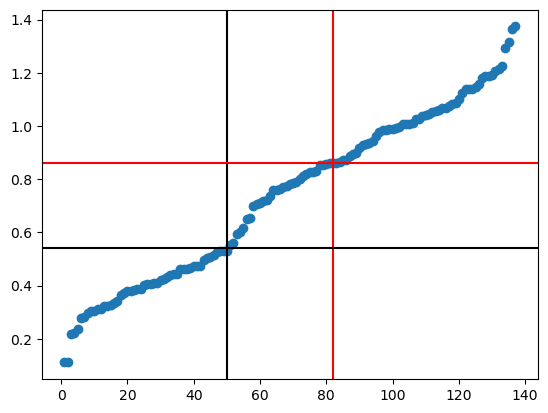

In [185]:
plt.scatter(somvar_negs["ranked_germprobs"],somvar_negs["germ_prob"] )
plt.axvline(137-55, color='red')
plt.axhline(0.54, color='black')
plt.axvline(50, color='black')
plt.axhline(0.861661, color='red')



In [187]:
82-50

32